# Training yolov8 base model for license plate detection

In [ ]:
%pip install ultralytics roboflow

In [1]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display

display.clear_output()



In [ ]:
model = YOLO('yolov8n.pt')

## Training the model

change the path for dataset accordingly

In [ ]:
!yolo task=detect mode=train model=yolov8n.pt data=datasets/MY_LPR.v2i.yolov8/data.yaml epochs=40 imgsz=640 device=0

Ultralytics 8.3.91 🚀 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: task=detect, mode=train, model=model/best.pt, data=datasets/MY_LPR.v2i.yolov8/data.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train10, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, 


  0%|          | 0.00/755k [00:00<?, ?B/s]
 17%|█▋        | 128k/755k [00:00<00:01, 641kB/s]
 34%|███▍      | 256k/755k [00:00<00:01, 482kB/s]
 68%|██████▊   | 512k/755k [00:00<00:00, 814kB/s]
 85%|████████▍ | 640k/755k [00:00<00:00, 918kB/s]
100%|██████████| 755k/755k [00:00<00:00, 925kB/s]
100%|██████████| 755k/755k [00:00<00:00, 822kB/s]

  0%|          | 0.00/5.35M [00:00<?, ?B/s]
  2%|▏         | 128k/5.35M [00:00<00:17, 307kB/s]
  5%|▍         | 256k/5.35M [00:01<00:22, 235kB/s]
  7%|▋         | 384k/5.35M [00:01<00:23, 218kB/s]
  9%|▉         | 512k/5.35M [00:02<00:22, 222kB/s]
 12%|█▏        | 640k/5.35M [00:02<00:21, 233kB/s]
 14%|█▍        | 768k/5.35M [00:03<00:23, 203kB/s]
 16%|█▋        | 896k/5.35M [00:04<00:25, 188kB/s]
 19%|█▊        | 1.00M/5.35M [00:05<00:24, 185kB/s]
 21%|██        | 1.12M/5.35M [00:05<00:22, 193kB/s]
 23%|██▎       | 1.25M/5.35M [00:06<00:20, 210kB/s]
 26%|██▌       | 1.38M/5.35M [00:06<00:17, 233kB/s]
 28%|██▊       | 1.50M/5.35M [00:07<00:15, 264

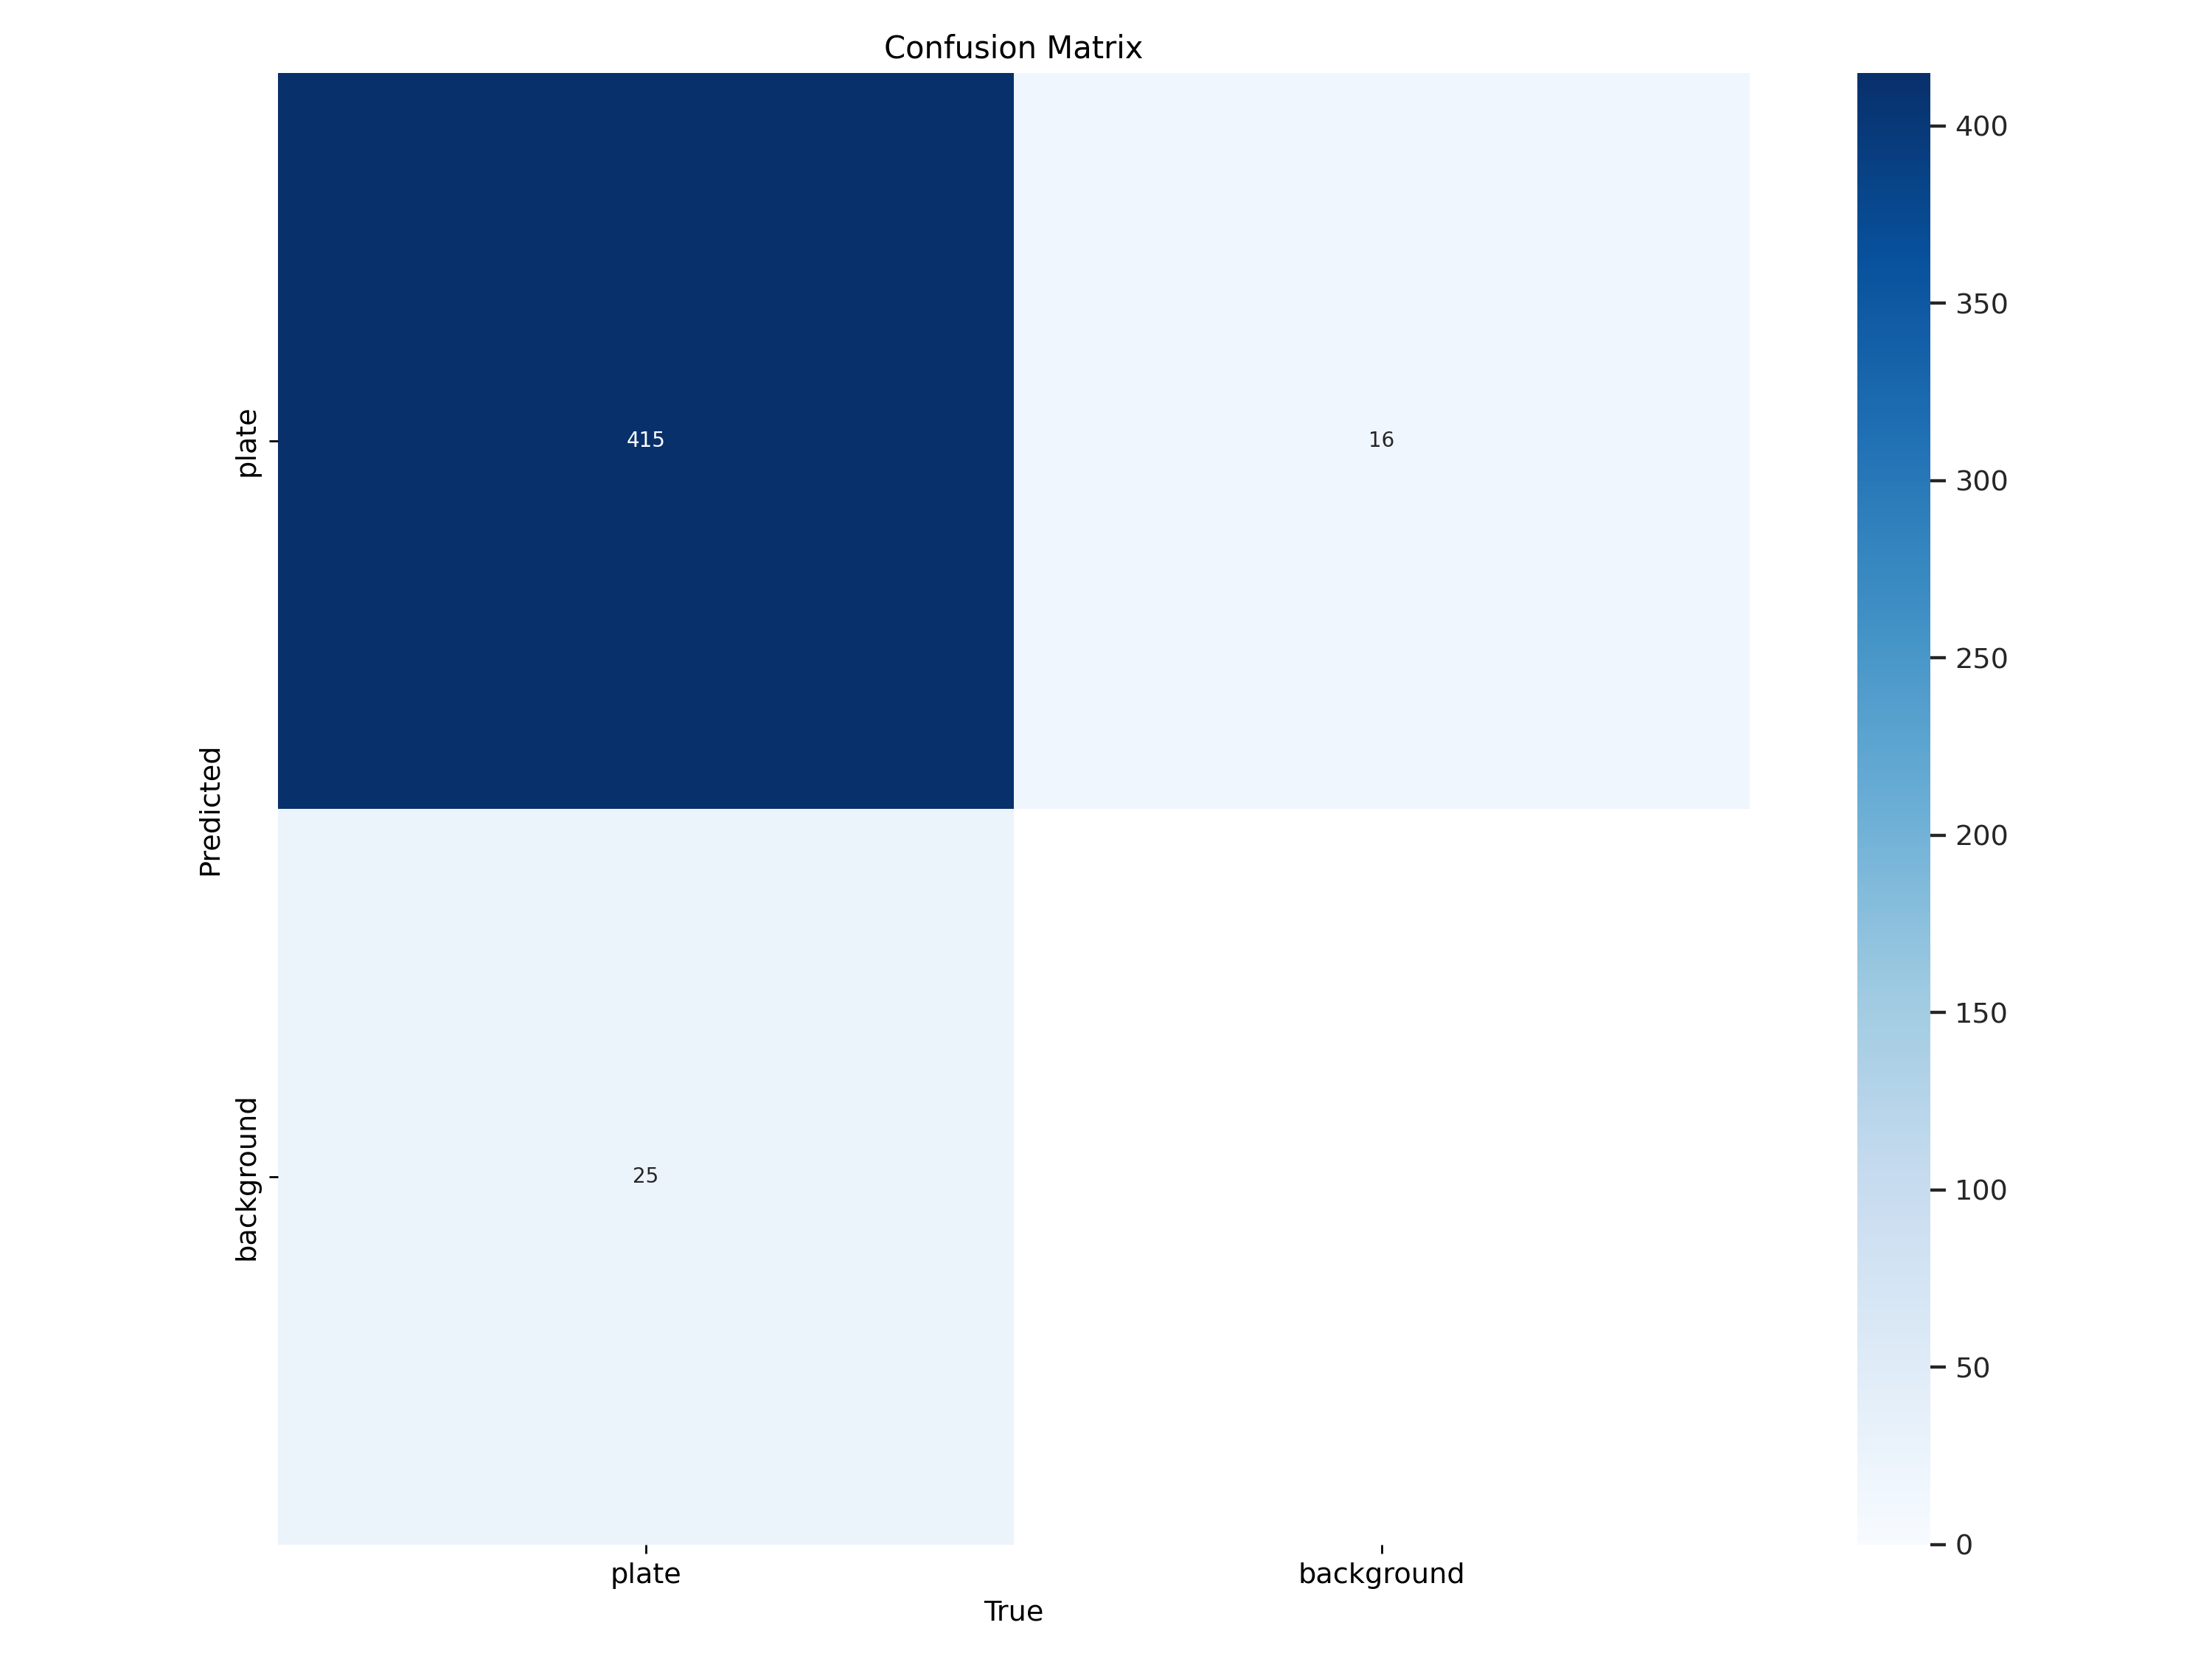

In [6]:
Image(filename=f'/content/runs/detect/train/confusion_matrix.png', width = 600)

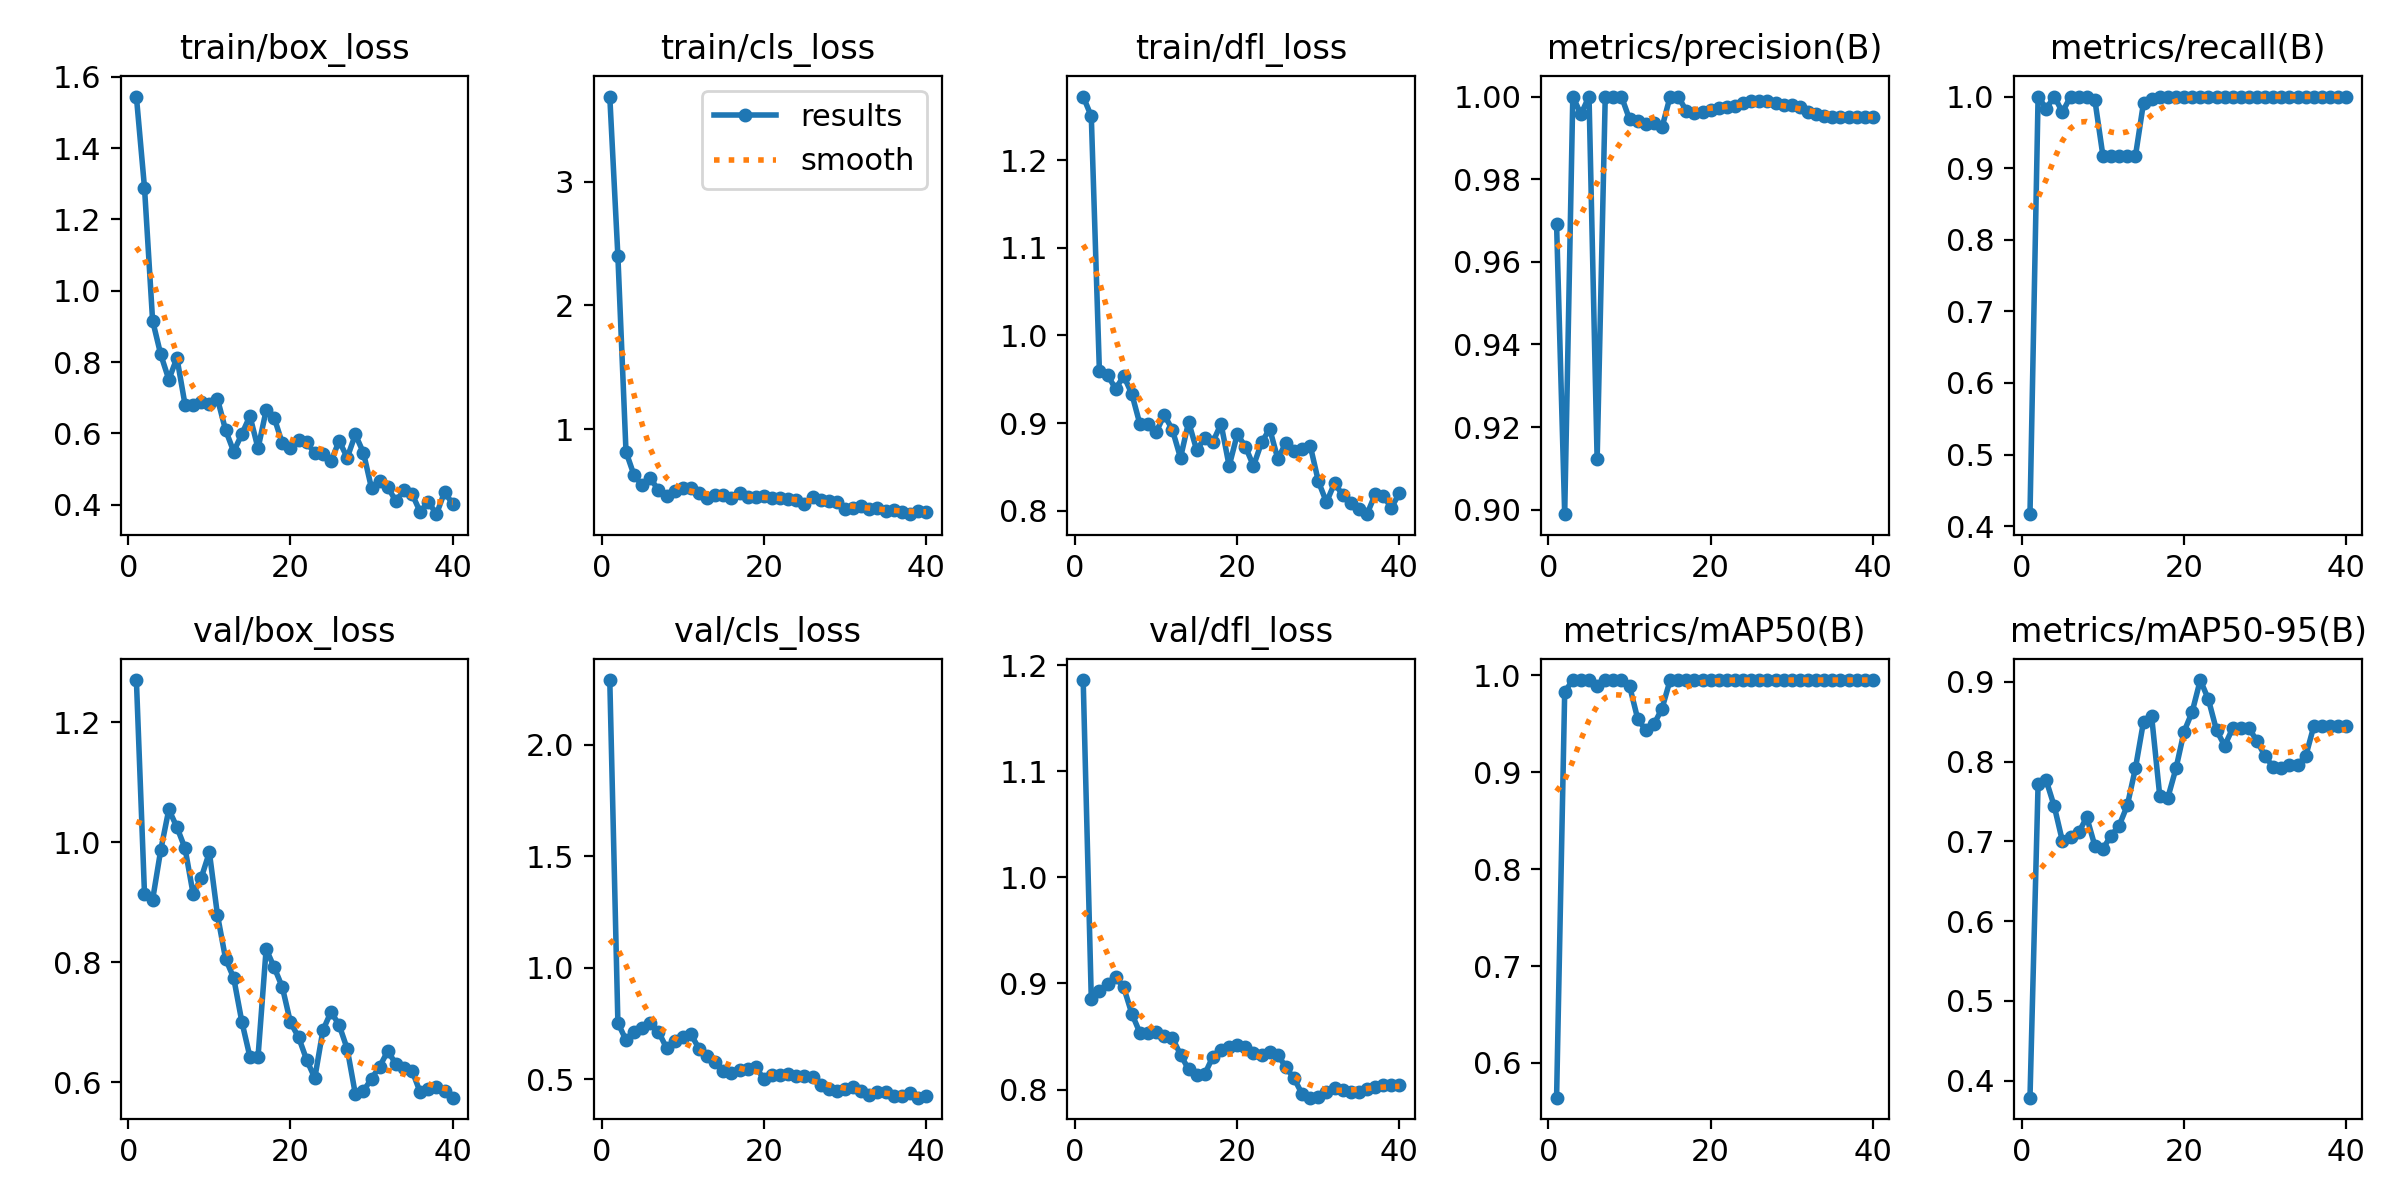

In [8]:
Image(filename=f'runs/detect/train10/results.png', width = 600)

## Validating the trained model

In [ ]:
!yolo task=detect mode=val model=runs/detect/train10/weights/best.pt data=datasets/MY_LPR.v2i.yolov8/data.yaml device=0

Ultralytics 8.3.91 🚀 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
                   all         12         12      0.997          1      0.995       0.89
Speed: 0.7ms preprocess, 14.8ms inference, 0.0ms loss, 11.4ms postprocess per image
Results saved to runs\detect\val
💡 Learn more at https://docs.ultralytics.com/modes/val



val: Scanning E:\Raspberry Pi\ParkSense\datasets\MY_LPR.v2i.yolov8\valid\labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100%|██████████| 12/12 [00:00<?, ?it/s]
val: Scanning E:\Raspberry Pi\ParkSense\datasets\MY_LPR.v2i.yolov8\valid\labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100%|██████████| 12/12 [00:00<?, ?it/s]

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/1 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:06<00:00,  6.53s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:06<00:00,  6.53s/it]


## Tesiting the trained model

In [ ]:
!yolo task=detect mode=predict model=runs/detect/train10/weights/best.pt conf=0.5 source=datasets/MY_LPR.v2i.yolov8/test/images/

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob('runs/detect/predict/*.jpg'):
  display(Image(filename=image_path, width=600))
  print("\n")

## Exporting the model

In [ ]:
!pip install --no-cache-dir "sng4onnx>=1.0.1" "onnxslim>=0.1.31" "tflite_support" "onnxruntime" "protobuf" "ai-edge-litert" --extra-index-url https://pypi.ngc.nvidia.com

In [ ]:
from ultralytics import YOLO
model=YOLO('runs/detect/train10/weights/best.pt')
model.export(format='tflite')